# Evaluate Face to Hair Mapper


In [1]:
from __future__ import annotations

import math
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from systems.static_auto_tryon.auto_app.ml.datasets import read_jsonl_manifest
from systems.static_auto_tryon.auto_app.ml.face_to_hair_mapper import (
    HAIR_FIELDS,
    evaluate_mapper_predictions,
    load_mapper_payload,
    recommend_assets_for_face,
)

PROJECT_ROOT


WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
DATASET_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'datasets' / 'face_to_hair_mapper_strong'
VAL_MANIFEST = DATASET_ROOT / 'val.jsonl'
SUMMARY_PATH = DATASET_ROOT / 'summary.json'

ASSET_BANK_PATH = PROJECT_ROOT / 'backend' / 'data' / 'processed' / 'celeba_hair_rich_assets' / 'reviewed' / 'kept_assets_labeled_enriched.jsonl'
CONFIG_PATH = PROJECT_ROOT / 'backend' / 'models' / 'face_to_hair_mapper_light' / 'mapper_config.json'
METRIC_SUMMARY_PATH = PROJECT_ROOT / 'backend' / 'models' / 'face_to_hair_mapper_light' / 'mapper_summary.json'

FACE_IMAGE_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw' / 'celeba' / 'img_align_celeba' / 'img_align_celeba'
if not FACE_IMAGE_ROOT.exists():
    FACE_IMAGE_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw' / 'celeba' / 'img_align_celeba'


In [3]:
val_records = read_jsonl_manifest(VAL_MANIFEST)
asset_rows = read_jsonl_manifest(ASSET_BANK_PATH)
dataset_summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8')) if SUMMARY_PATH.exists() else {}
metric_summary = json.loads(METRIC_SUMMARY_PATH.read_text(encoding='utf-8')) if METRIC_SUMMARY_PATH.exists() else {}
mapper_payload = load_mapper_payload(CONFIG_PATH)
metrics = evaluate_mapper_predictions(val_records, mapper_payload)
prediction_frame = pd.DataFrame(metrics['prediction_rows'])

pd.Series({
    'mapper_type': mapper_payload.get('mapper_type'),
    'val_records': len(val_records),
    'asset_rows': len(asset_rows),
    'exact_match_accuracy': metrics['exact_match_accuracy'],
    **metrics['field_accuracy'],
})


mapper_type             lightweight_frequency_mapper
val_records                                       18
asset_rows                                       120
exact_match_accuracy                             0.0
length                                      0.555556
curl                                        0.444444
style_family                                0.111111
dtype: object

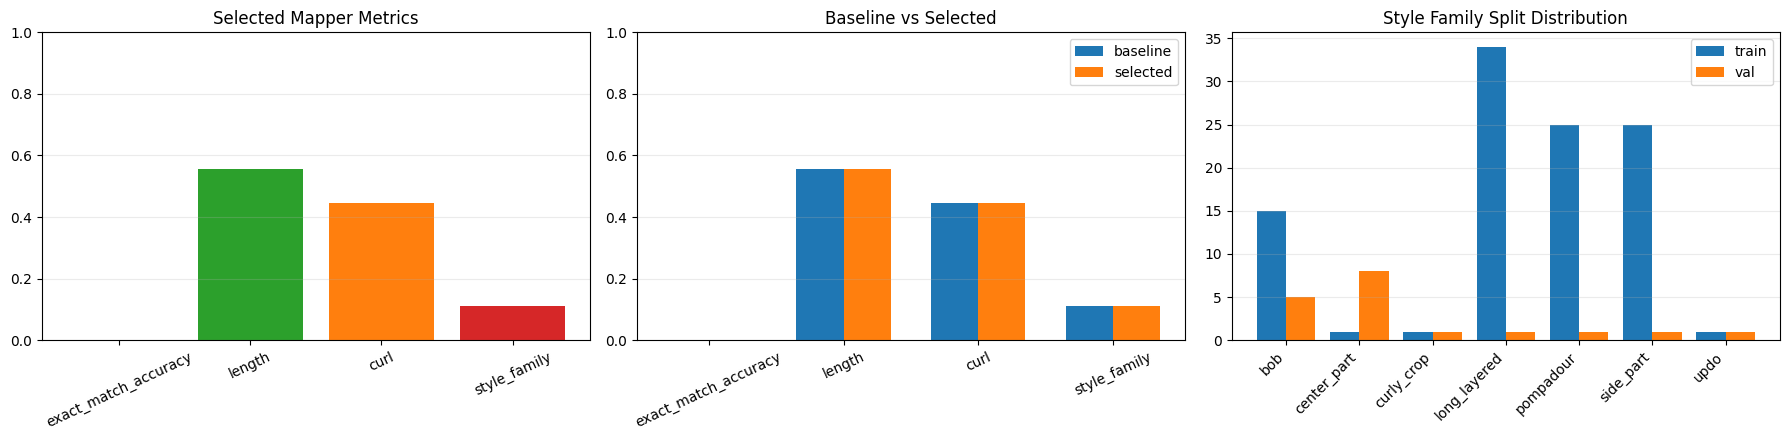

In [4]:
baseline_metrics = metric_summary.get('baseline_metrics', {})
selected_metrics = metric_summary.get('selected_metrics', {})

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metric_names = ['exact_match_accuracy', *HAIR_FIELDS]
metric_values = [metrics['exact_match_accuracy'], *[metrics['field_accuracy'][field] for field in HAIR_FIELDS]]
axes[0].bar(metric_names, metric_values, color=['tab:blue', 'tab:green', 'tab:orange', 'tab:red'])
axes[0].set_title('Selected Mapper Metrics')
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.25)

if baseline_metrics and selected_metrics:
    compare_rows = ['exact_match_accuracy', *HAIR_FIELDS]
    baseline_values = [baseline_metrics.get('exact_match_accuracy', 0.0), *[baseline_metrics.get('field_accuracy', {}).get(field, 0.0) for field in HAIR_FIELDS]]
    selected_values = [selected_metrics.get('exact_match_accuracy', 0.0), *[selected_metrics.get('field_accuracy', {}).get(field, 0.0) for field in HAIR_FIELDS]]
    positions = np.arange(len(compare_rows))
    width = 0.35
    axes[1].bar(positions - width / 2, baseline_values, width=width, label='baseline')
    axes[1].bar(positions + width / 2, selected_values, width=width, label='selected')
    axes[1].set_xticks(positions)
    axes[1].set_xticklabels(compare_rows, rotation=25)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title('Baseline vs Selected')
    axes[1].grid(axis='y', alpha=0.25)
    axes[1].legend()
else:
    axes[1].axis('off')
    axes[1].set_title('No baseline comparison found')

train_counts = dataset_summary.get('train_hair_field_counts', {})
val_counts = dataset_summary.get('val_hair_field_counts', {})
style_labels = sorted(set(train_counts.get('style_family', {}).keys()) | set(val_counts.get('style_family', {}).keys()))
train_style_values = [train_counts.get('style_family', {}).get(label, 0) for label in style_labels]
val_style_values = [val_counts.get('style_family', {}).get(label, 0) for label in style_labels]
positions = np.arange(len(style_labels))
width = 0.4
axes[2].bar(positions - width / 2, train_style_values, width=width, label='train')
axes[2].bar(positions + width / 2, val_style_values, width=width, label='val')
axes[2].set_xticks(positions)
axes[2].set_xticklabels(style_labels, rotation=45, ha='right')
axes[2].set_title('Style Family Split Distribution')
axes[2].grid(axis='y', alpha=0.25)
axes[2].legend()

plt.tight_layout()
plt.show()


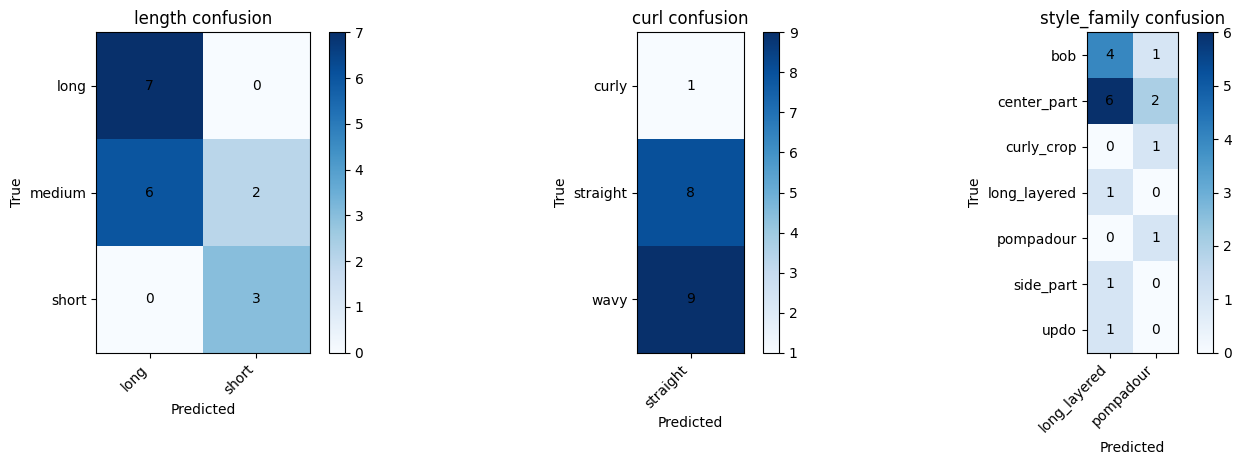

pred_length,long,short
true_length,,
long,7,0
medium,6,2
short,0,3


In [5]:
confusion_frames = {}
fig, axes = plt.subplots(1, len(HAIR_FIELDS), figsize=(4.75 * len(HAIR_FIELDS), 4.75))
if len(HAIR_FIELDS) == 1:
    axes = [axes]

for axis, field in zip(axes, HAIR_FIELDS):
    confusion = pd.crosstab(
        prediction_frame[f'true_{field}'],
        prediction_frame[f'pred_{field}'],
        dropna=False,
    )
    confusion_frames[field] = confusion
    image = axis.imshow(confusion.values, cmap='Blues')
    axis.set_title(f'{field} confusion')
    axis.set_xlabel('Predicted')
    axis.set_ylabel('True')
    axis.set_xticks(range(confusion.shape[1]))
    axis.set_xticklabels(confusion.columns, rotation=45, ha='right')
    axis.set_yticks(range(confusion.shape[0]))
    axis.set_yticklabels(confusion.index)
    for row_idx in range(confusion.shape[0]):
        for col_idx in range(confusion.shape[1]):
            axis.text(col_idx, row_idx, int(confusion.iat[row_idx, col_idx]), ha='center', va='center', color='black')
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

confusion_frames[HAIR_FIELDS[0]]


In [6]:
prediction_frame = prediction_frame.assign(
    all_correct=(prediction_frame[[f'correct_{field}' for field in HAIR_FIELDS]].all(axis=1)),
    mean_correctness=prediction_frame[[f'correct_{field}' for field in HAIR_FIELDS]].mean(axis=1),
)
prediction_frame.sort_values(['all_correct', 'mean_correctness'], ascending=[True, True]).head(10)


,asset_id,source_id,true_length,pred_length,correct_length,true_curl,pred_curl,correct_curl,true_style_family,pred_style_family,correct_style_family,all_correct,mean_correctness
14,celeba_hair_000016,000024.jpg,medium,long,False,wavy,straight,False,bob,long_layered,False,False,0.000000
16,celeba_hair_000062,000096.jpg,medium,long,False,wavy,straight,False,bob,long_layered,False,False,0.000000
1,celeba_hair_000188,000323.jpg,long,long,True,wavy,straight,False,center_part,long_layered,False,False,0.333333
2,celeba_hair_000233,000398.jpg,short,short,True,wavy,straight,False,center_part,pompadour,False,False,0.333333
3,celeba_hair_000161,000277.jpg,short,short,True,curly,straight,False,curly_crop,pompadour,False,False,0.333333
4,celeba_hair_000027,000040.jpg,medium,long,False,straight,straight,True,updo,long_layered,False,False,0.333333
5,celeba_hair_000100,000175.jpg,medium,long,False,straight,straight,True,side_part,long_layered,False,False,0.333333
8,celeba_hair_000205,000349.jpg,long,long,True,wavy,straight,False,center_part,long_layered,False,False,0.333333
9,celeba_hair_000106,000183.jpg,medium,long,False,straight,straight,True,bob,long_layered,False,False,0.333333
10,celeba_hair_000032,000048.jpg,medium,short,False,straight,straight,True,bob,pompadour,False,False,0.333333


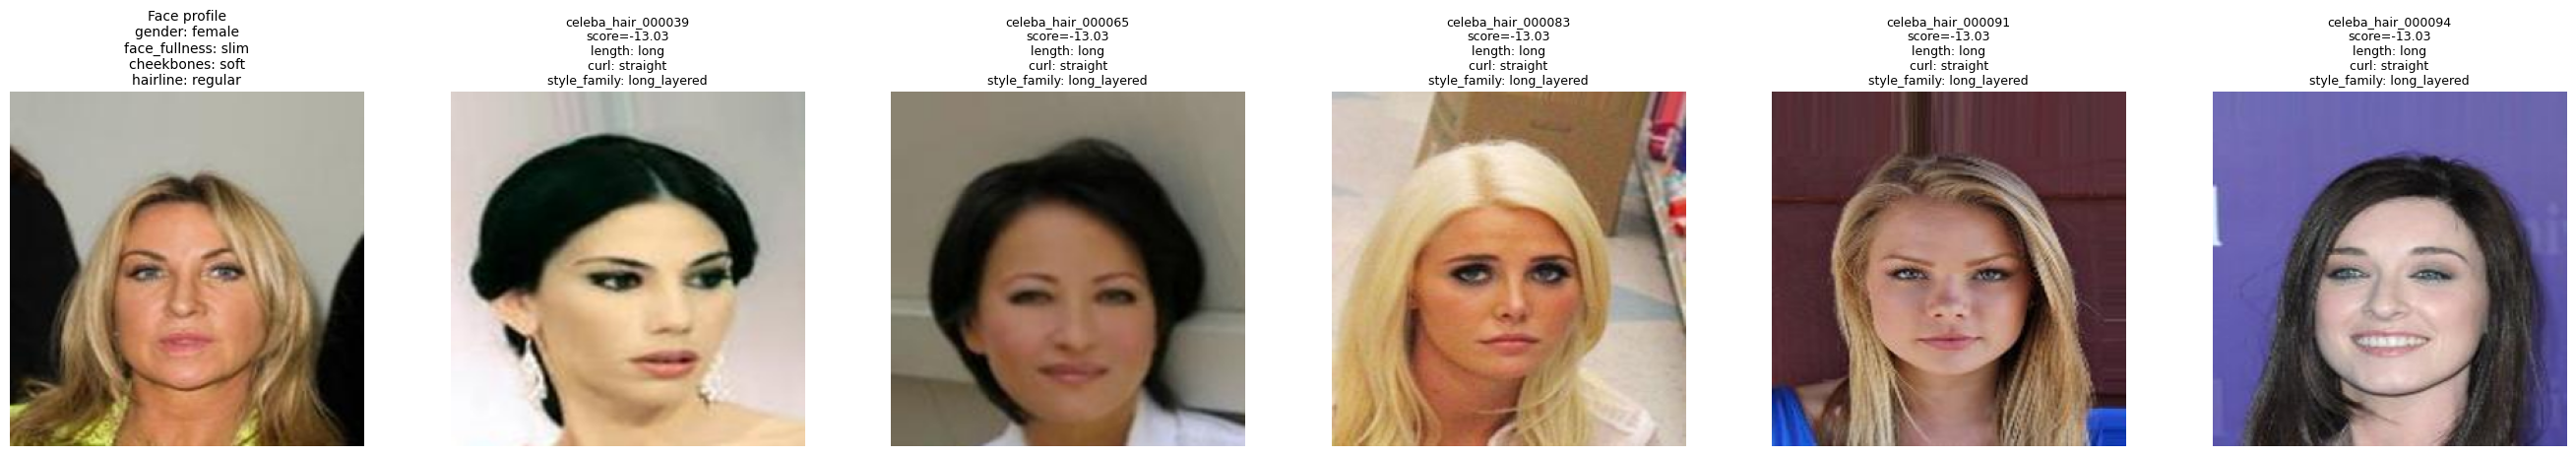

,asset_id,source_id,image_path,score,hair_labels,gender_label
0,celeba_hair_000039,000057.jpg,D:\Projects\Personal Projects\Hairstyle Recomm...,-13.032574,"{'length': 'long', 'curl': 'straight', 'style_...",female
1,celeba_hair_000065,000101.jpg,D:\Projects\Personal Projects\Hairstyle Recomm...,-13.032574,"{'length': 'long', 'curl': 'straight', 'style_...",female
2,celeba_hair_000083,000140.jpg,D:\Projects\Personal Projects\Hairstyle Recomm...,-13.032574,"{'length': 'long', 'curl': 'straight', 'style_...",female
3,celeba_hair_000091,000157.jpg,D:\Projects\Personal Projects\Hairstyle Recomm...,-13.032574,"{'length': 'long', 'curl': 'straight', 'style_...",female
4,celeba_hair_000094,000161.jpg,D:\Projects\Personal Projects\Hairstyle Recomm...,-13.032574,"{'length': 'long', 'curl': 'straight', 'style_...",female


In [7]:
def show_mapper_case(case_index: int = 0, top_k: int = 5):
    record = val_records[case_index]
    face_labels = record['face_labels']
    recommendation_rows = recommend_assets_for_face(face_labels, asset_rows, mapper_payload, top_k=top_k)
    recommendation_frame = pd.DataFrame(recommendation_rows)

    figure_columns = top_k + 1
    fig, axes = plt.subplots(1, figure_columns, figsize=(4.5 * figure_columns, 4.5))

    face_image_path = FACE_IMAGE_ROOT / str(record['source_id'])
    if face_image_path.exists():
        with Image.open(face_image_path).convert('RGB') as image:
            axes[0].imshow(image.resize((256, 256)))
    axes[0].set_title('Face profile\n' + '\n'.join(f"{key}: {value}" for key, value in face_labels.items()), fontsize=10)
    axes[0].axis('off')

    for axis, row in zip(axes[1:], recommendation_rows):
        asset_path = Path(row['image_path'])
        if asset_path.exists():
            with Image.open(asset_path).convert('RGB') as image:
                axis.imshow(image.resize((256, 256)))
        title_lines = [row['asset_id'], f"score={row['score']:.2f}"]
        for field in HAIR_FIELDS:
            title_lines.append(f"{field}: {row['hair_labels'].get(field, '')}")
        axis.set_title('\n'.join(title_lines), fontsize=9)
        axis.axis('off')

    plt.tight_layout()
    plt.show()
    return recommendation_frame

show_mapper_case(case_index=0, top_k=5)
